In [1]:
import pandas as pd
import sqlite3
import os
from pathlib import Path
import numpy
import seaborn as sns
import peewee as pw
import matplotlib.pyplot as plt
import sklearn as skl

#swithc working directory to 
os.chdir(r'c:\Repositories\asphalt-db')
from main.data_classifications import *
from main.data_processing import *
from src.db_builder.models import *
from main.query_database import *

sns.set_style('whitegrid')
working_dir = Path(r'c:\Repositories\asphalt-db\results')
results_dir = Path(r'c:\Users\klerk_wj\OneDrive - Stichting Deltares\00_Projecten\09_Kvk Asfalt\results')

# Importeren van de database

In [2]:
# Read into a pandas DataFrame
dikes_and_projects = query_dikes_and_projects(sqlite3.connect(working_dir.parent.joinpath('data','database_all_v5.sqlite')))
df_final = load_and_merge_data(working_dir.parent.joinpath('data','database_all_v5.sqlite'))
data_per_dike_project = get_section_based_statistics(df_final, dikes_and_projects)
df_final, data_per_dike_project = classifications_wrapper(df_final, data_per_dike_project)


<Axes: xlabel='age_at_investigation', ylabel='sig_b'>

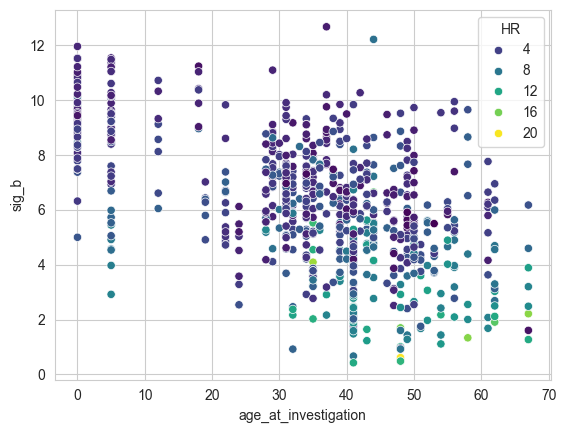

In [3]:
#make as scatter plot of age_at_investigation vs sig_b, colored by HR_category
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')

In [4]:
#Export voor regressie
data_for_regression = df_final[['borehole_id','age_at_investigation', 'sig_b', 'HR']]
#rename sig_b to str and age_at_investigation to age and HR to void
data_for_regression = data_for_regression.rename(columns={'sig_b':'str', 'age_at_investigation':'age', 'HR':'void'})
#export to xlsx
data_for_regression.to_excel(working_dir.joinpath('data_for_regression.xlsx'), index=False)
                               
    

## Maken van dataframe op projectniveau

## Toevoegen van extra classificaties
Bros/ductiel (V_ber)
Sterk/gemiddeld/zwak (sig_b)
Heterogeniteit (o.b.v sig_b_CoV)

<Axes: xlabel='V_Ber', ylabel='sig_b'>

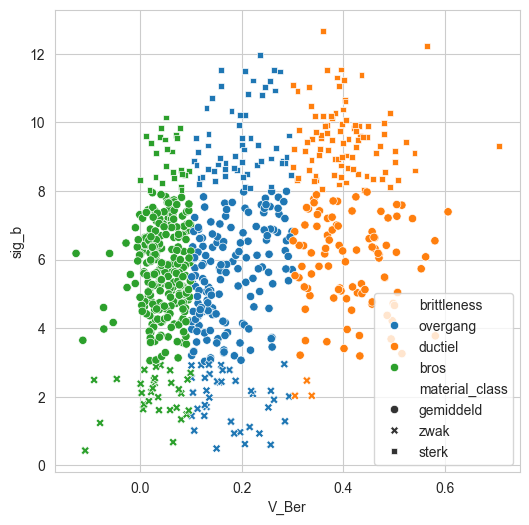

In [5]:

fig,ax = plt.subplots(figsize=(6, 6), ncols=1)
sns.scatterplot(data=df_final, x='V_Ber', y='sig_b', hue='brittleness',style='material_class', palette='tab10', ax=ax)


In [6]:
data_per_dike_project

,borehole_id,project_dike_id,construction_year,investigation_year,project_id,dike_id,project_name,dike_name,waterboard,age_at_investigation,...,pha_50_cov,sig_cyc_cov,sig_perm_cov,E_ini_cov,E_50_cov,N_fat_cov,HR_cov,bitumen_cov,heterogeneity_category,construction_year_category
0,1,1,1984,2006,1,1,P_0601831,"het_flaauwe_werk_29,6 - 48,5",Hollandse Delta,22,...,0.132260,0.383971,0.023174,0.107258,0.066684,1.074097,0.243259,NaN,Homogeen,1973-2000
1,9,2,1959,2007,2,2,P_0702493,hellegatsdam_-,Rijkswaterstaat Zuid-Holland Waterdistrict Har...,48,...,0.247500,0.645213,0.020906,0.283323,0.263836,1.155408,0.511842,0.027918,Heterogeen,before 1973
2,25,3,1977,2009,3,3,P_0802158,"t_schoor_-_veerdam_holwerd_40,7 - 49,75",Wetterskip Fryslân,32,...,0.491943,0.432013,0.416429,2.821957,0.216079,1.916977,0.631492,0.048994,Heterogeen,1973-2000
3,34,4,1977,2009,3,4,P_0802158,"zurichoord_6,55 - 7,4",Wetterskip Fryslân,32,...,0.213178,0.346888,0.331629,0.142695,0.101209,1.637312,0.327297,0.032286,Homogeen,1973-2000
4,18,5,1975,2009,3,5,P_0802158,"paesens_-_wierum_49,75 - 55,3",Wetterskip Fryslân,34,...,0.297501,0.353303,0.342894,0.085130,0.072947,1.839949,0.314560,0.069645,Matig heterogeen,1973-2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,701,92,2019,2024,35,50,P_2401206,"proefvakken_pov-wadden_-_vak_7_(westhoek)_17,8...",Wetterskip Fryslân,5,...,NaN,NaN,NaN,NaN,NaN,NaN,0.372607,NaN,Homogeen,after 2000
92,713,93,1982,2017,36,83,P_1702899,"zwarte_haan_-_westrand_groene_dijk_19,6 - 26,5",Wetterskip Fryslân,35,...,0.300590,0.377784,0.362925,0.158516,0.136166,1.806847,0.334351,0.025056,Matig heterogeen,1973-2000
93,721,94,1993,2017,36,84,P_1702899,"oostrand_groene_dijk_-_holwerd_37,9 - 40,7",Wetterskip Fryslân,24,...,0.316480,0.433177,0.417166,0.189983,0.127076,1.302448,0.463337,0.022461,Matig heterogeen,1973-2000
94,729,95,1976,2017,36,85,P_1702899,"t_schoor_-_wierum_46,1 - 49,7",Wetterskip Fryslân,41,...,0.390850,0.331502,0.316790,0.141534,0.159869,1.574421,0.541958,0.253833,Matig heterogeen,1973-2000


<Axes: xlabel='age_at_investigation', ylabel='sig_b_mean'>

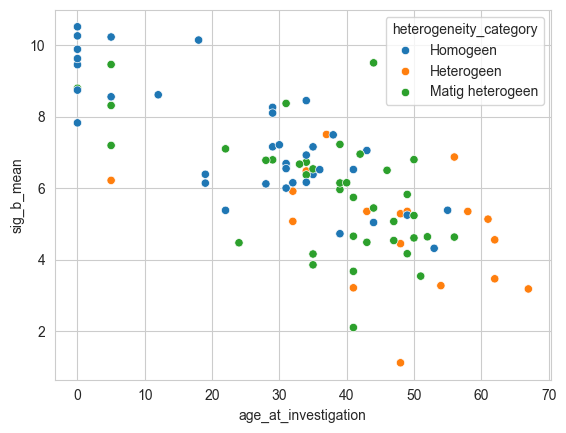

In [7]:
#scatterplot of age_at_investigation vs sig_b_mean, colored by heterogeneity_category
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', palette='tab10')


# Analyses

## Filtering van de data/uitsluiten

### Impact uitsluiten van HR > 9%: welke punten verdwijnen?

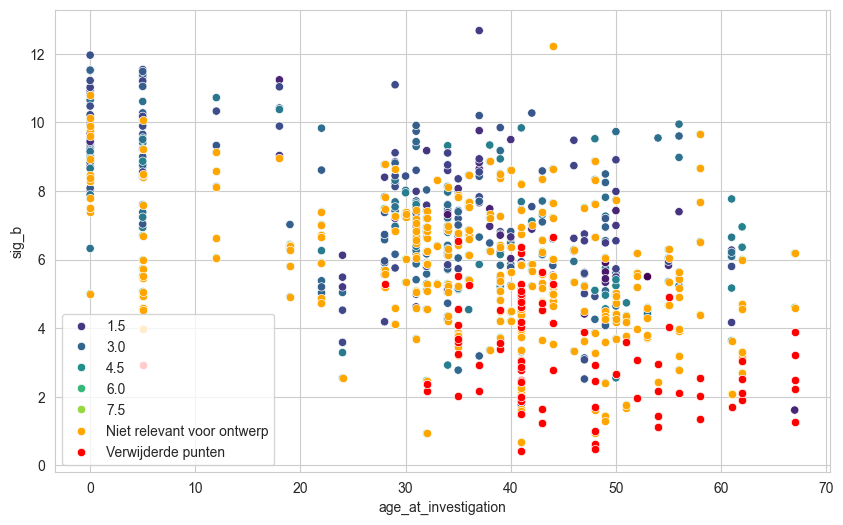

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
threshold_hr = 9
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] < threshold_hr], x='age_at_investigation', y='sig_b', hue='HR',palette='viridis')
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] > 4], x='age_at_investigation', y='sig_b', color= 'orange', label = 'Niet relevant voor ontwerp')
sns.scatterplot(ax=ax, data=df_final.loc[df_final['HR'] > threshold_hr], x='age_at_investigation', y='sig_b', color= 'red', label = 'Verwijderde punten')
plt.legend()

### Heterogeniteit

(-0.5, 70.0)

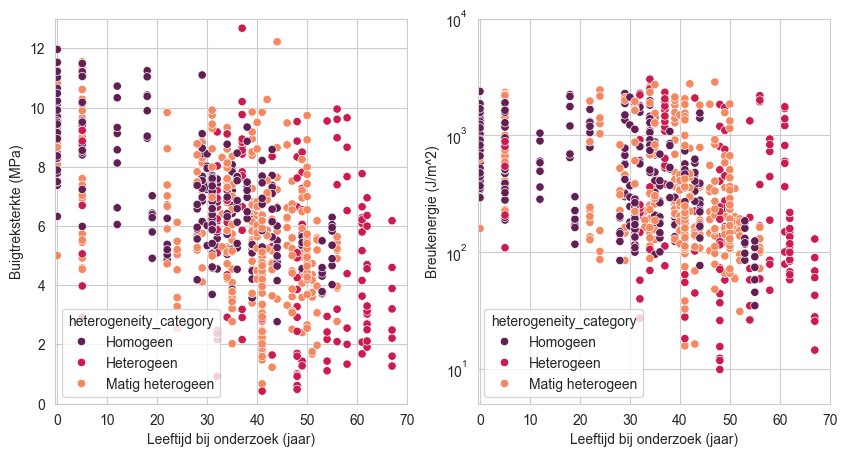

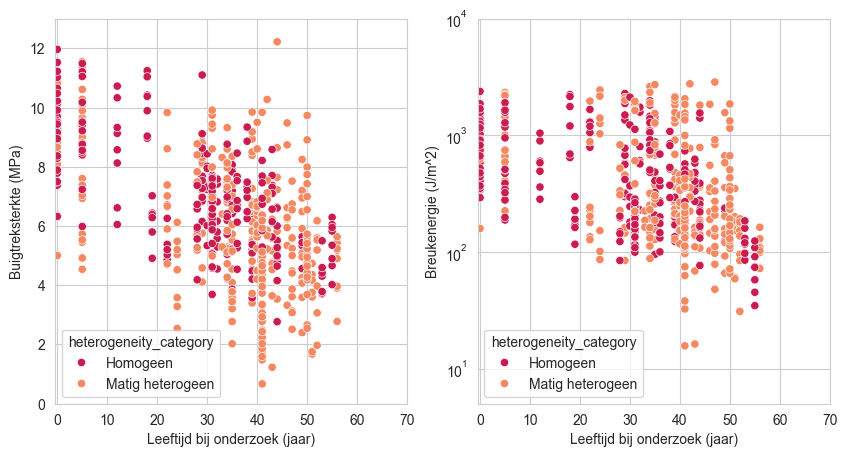

In [9]:
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='heterogeneity_category', palette='rocket', ax=ax[0])
sns.scatterplot(data=df_final, x='age_at_investigation', y='G_c', hue='heterogeneity_category', palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='sig_b', hue='heterogeneity_category', palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[0])
sns.scatterplot(data=df_final.loc[df_final['heterogeneity_category'] != 'Heterogeen'], x='age_at_investigation', y='G_c', hue='heterogeneity_category', palette=sns.color_palette('rocket',n_colors=3)[1:], ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Buigtreksterkte (MPa)')
ax[1].set_ylabel('Breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[0].set_ylim(0, 13)
ax[1].set_ylim(5, 10000)
ax[0].set_xlim(-0.5, 70)
ax[1].set_xlim(-0.5, 70)

Text(0.5, 0, 'Leeftijd bij onderzoek (jaar)')

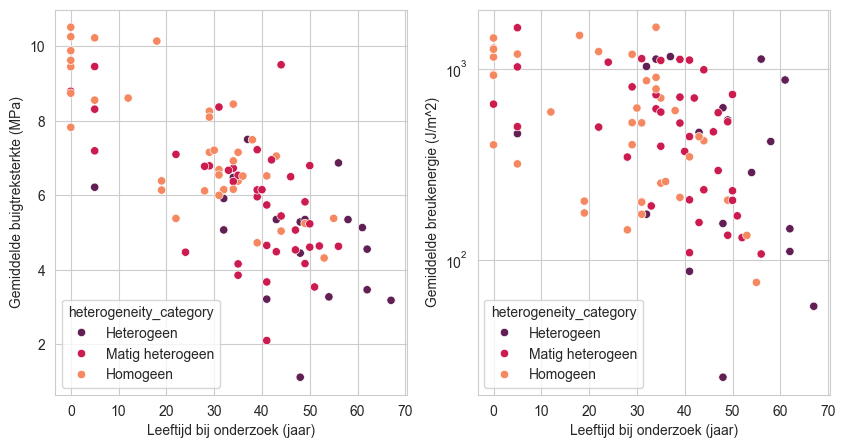

In [10]:
#same but for data_per_dike_project
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='sig_b_mean', hue='heterogeneity_category', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], palette='rocket', ax=ax[0])
sns.scatterplot(data=data_per_dike_project, x='age_at_investigation', y='G_c_mean', hue='heterogeneity_category', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], palette='rocket', ax=ax[1])
ax[1].set_yscale('log')
ax[0].set_ylabel('Gemiddelde buigtreksterkte (MPa)')
ax[1].set_ylabel('Gemiddelde breukenergie (J/m^2)')
ax[0].set_xlabel('Leeftijd bij onderzoek (jaar)')
ax[1].set_xlabel('Leeftijd bij onderzoek (jaar)')

Text(0, 0.5, '')

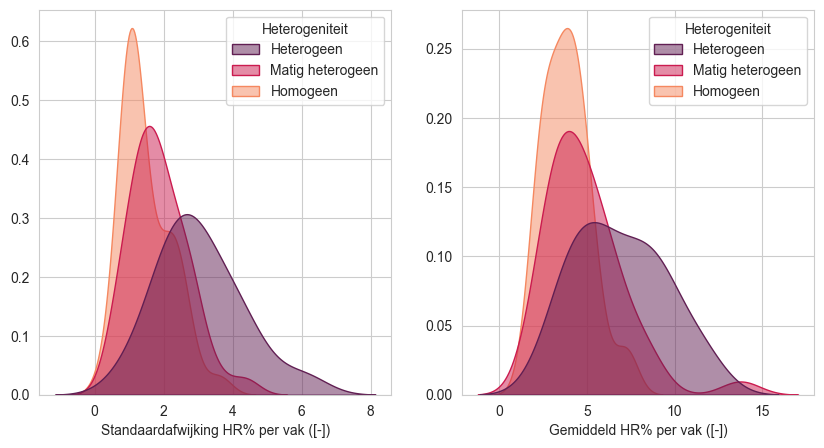

In [11]:
#density plot van heterogeniteitscategorie (als hue) met HR_std voor secties
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.kdeplot(data=data_per_dike_project.rename(columns={'heterogeneity_category' : 'Heterogeniteit'}), x='HR_std', hue='Heterogeniteit', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], fill=True, common_norm=False, palette='rocket', alpha=0.5, ax=ax[0])
sns.kdeplot(data=data_per_dike_project.rename(columns={'heterogeneity_category' : 'Heterogeniteit'}), x='HR_mean', hue='Heterogeniteit', hue_order = ['Heterogeen', 'Matig heterogeen', 'Homogeen'], fill=True, common_norm=False, palette='rocket', alpha=0.5, ax=ax[1])
ax[0].set_xlabel('Standaardafwijking HR% per vak ([-])')
ax[1].set_xlabel('Gemiddeld HR% per vak ([-])')
ax[0].set_ylabel('')
ax[1].set_ylabel('')
#rename legend title but keep the rest of the legend the same
# ax[0].legend(handles=ax[0].get_legend_handles_labels()[0], labels=ax[0].get_legend_handles_labels()[1], title='Heterogeniteitscategorie')
# ax[1].legend(handles=ax[1].get_legend_handles_labels()[0], labels=ax[1].get_legend_handles_labels()[1], title='Heterogeniteitscategorie')

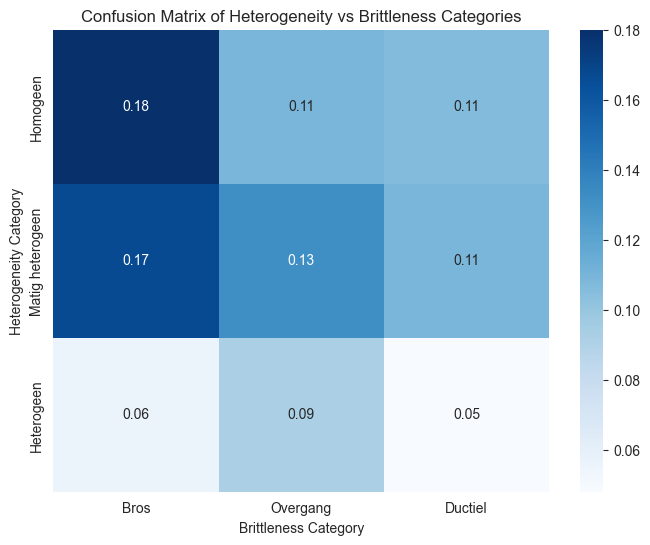

In [12]:
#check how often heterogeneity categories correspond to brittleness categories
df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
#make a confusion matrix heatmap of the above
confusion_matrix = df_final.groupby(['heterogeneity_category', 'brittleness']).size().unstack(fill_value=0)
plt.figure(figsize=(8,6))
#ensure sequence of x is bros, overgang, ductiel and y is Homogeen, Matig heterogeen, Heterogeen. Normalize all values to sum to 1 in total
confusion_matrix = confusion_matrix.reindex(columns=['bros', 'overgang', 'ductiel'], index=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
sns.heatmap(confusion_matrix, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Bros', 'Overgang', 'Ductiel'], yticklabels=['Homogeen', 'Matig heterogeen', 'Heterogeen'])
plt.xlabel('Brittleness Category')
plt.ylabel('Heterogeneity Category')
plt.title('Confusion Matrix of Heterogeneity vs Brittleness Categories')
plt.show()

## Construction year

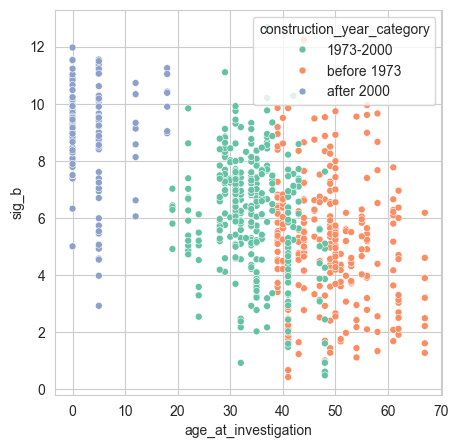

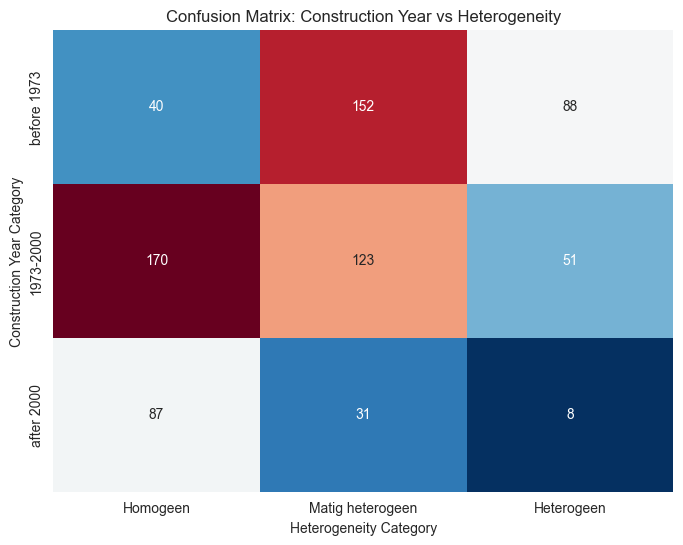

In [13]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='construction_year_category', ax=ax, s=25, palette='Set2')

#make a confusion plot for construction year category vs heterogeneity category
confusion_matrix = df_final.groupby(['construction_year_category', 'heterogeneity_category']).size().unstack(fill_value=0)
#ensure sequence of x is Homogeen, Matig heterogeen, Heterogeen and y is before 1973, 1973-2000, after 2000
confusion_matrix = confusion_matrix.reindex(columns=['Homogeen', 'Matig heterogeen', 'Heterogeen'], index=['before 1973', '1973-2000', 'after 2000'])
#normalize all values to sum to 1 in total
# confusion_matrix = confusion_matrix.div(confusion_matrix.sum().sum(), axis=0)
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix, annot=True, fmt=".0f", cmap='RdBu_r', cbar=False)
plt.xlabel('Heterogeneity Category')
plt.ylabel('Construction Year Category')
plt.title('Confusion Matrix: Construction Year vs Heterogeneity')
plt.show()


## Pooling

### Algemeen

Eerst kijken naar de correlaties in de data

Text(0.5, 1.0, 'Correlation Matrix of Mean Values per Dike Project')

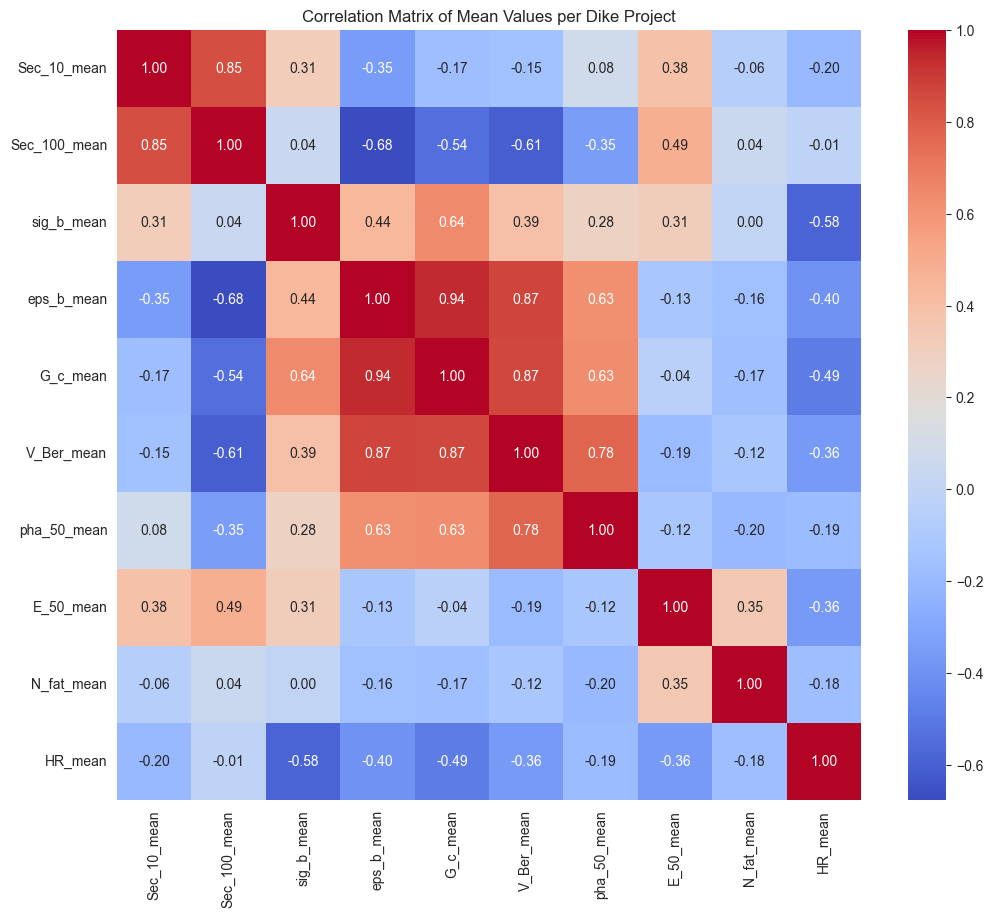

In [14]:
# correlaties bij data_per_dike_project
data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean', 'V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))

sns.heatmap(data_per_dike_project[['Sec_10_mean', 'Sec_100_mean', 'sig_b_mean', 'eps_b_mean', 'G_c_mean','V_Ber_mean', 'pha_50_mean', 'E_50_mean', 'N_fat_mean', 'HR_mean']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Mean Values per Dike Project')


{'Lagrange multiplier statistic': np.float64(nan), 'p-value': np.float64(nan), 'f-value': np.float64(nan), 'f p-value': np.float64(nan)}
{'Lagrange multiplier statistic': np.float64(nan), 'p-value': np.float64(nan), 'f-value': np.float64(nan), 'f p-value': np.float64(nan)}


<Axes: xlabel='age_at_investigation'>

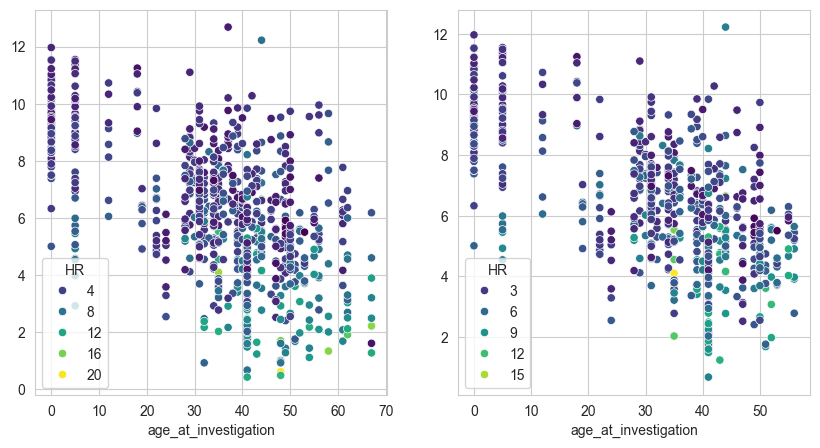

In [15]:
#Breusch-Pagan Lagrange Multiplier test for heteroscedasticity
from xml.parsers.expat import model
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

#run on df_final
X = df_final[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final['sig_b']
model1 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model1.resid, model1.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#run on df_final but without heterogeneneity category 'Heterogeen'
df_final_sub = df_final[df_final['heterogeneity_category'] != 'Heterogeen']
X = df_final_sub[['age_at_investigation']]
X = sm.add_constant(X)  # add constant term
y = df_final_sub['sig_b']
model2 = sm.OLS(y, X).fit()
bp_test = het_breuschpagan(model2.resid, model2.model.exog)
bp_labels = ['Lagrange multiplier statistic', 'p-value', 'f-value', 'f p-value']
print(dict(zip(bp_labels, bp_test)))

#plot both models and the data
fig, ax = plt.subplots(figsize=(10,5), ncols=2)
sns.scatterplot(data=df_final, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[0])
#add regression line from model1
sns.regplot(x=df_final['age_at_investigation'], y=model1.fittedvalues, scatter=False, ax=ax[0], color='red', label='Regression Line')
#show residuals as vertical lines
for i in range(len(df_final)):
    ax[0].vlines(x=df_final['age_at_investigation'].iloc[i], ymin=model1.fittedvalues.iloc[i], ymax=df_final['sig_b'].iloc[i], color='gray', alpha=0.5)

#same for model2
sns.scatterplot(data=df_final_sub, x='age_at_investigation', y='sig_b', hue='HR',palette='viridis', ax=ax[1])
#add regression line from model2
sns.regplot(x=df_final_sub['age_at_investigation'], y=model2.fittedvalues, scatter=False, ax=ax[1], color='red', label='Regression Line')

Text(0.5, 1.0, 'Correlation Matrix of Coefficient of Variation per Dike Project')

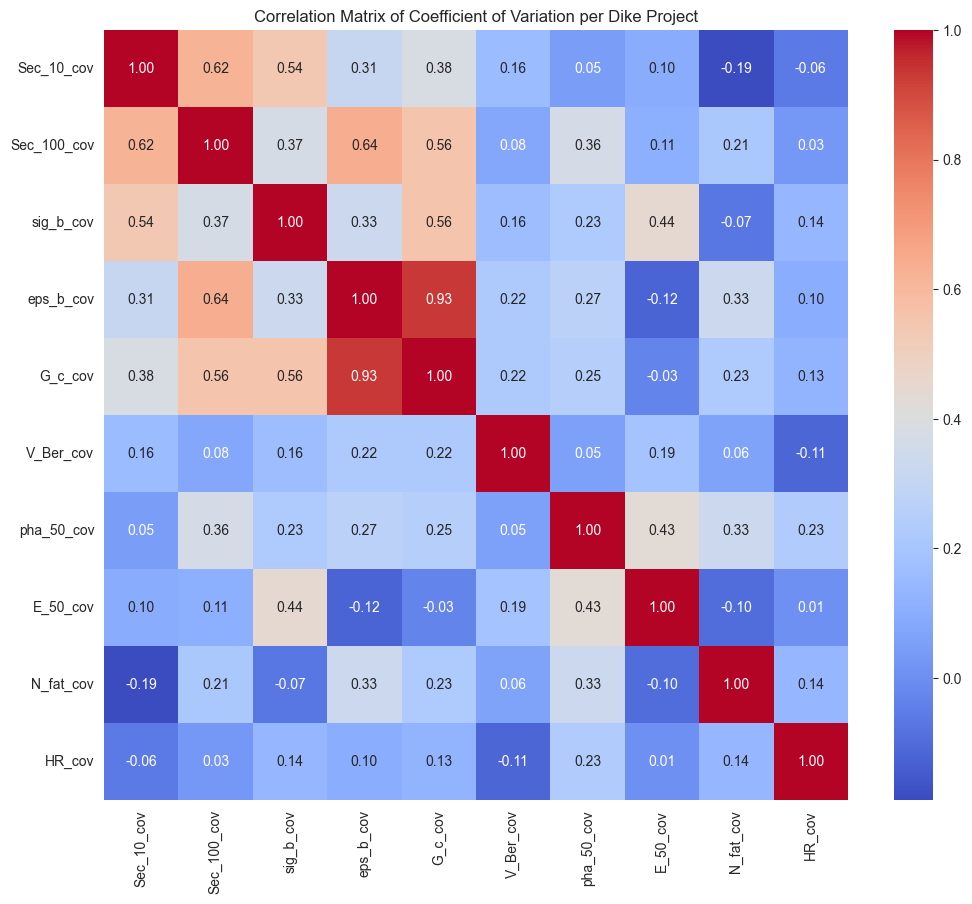

In [16]:
#zelfde voor CoV
data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr()
#heatmaps of the correlations
plt.figure(figsize=(12,10))
sns.heatmap(data_per_dike_project[['Sec_10_cov', 'Sec_100_cov', 'sig_b_cov', 'eps_b_cov', 'G_c_cov', 'V_Ber_cov', 'pha_50_cov', 'E_50_cov', 'N_fat_cov', 'HR_cov']].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Coefficient of Variation per Dike Project')

Text(0.5, 1.0, 'Pearson correlatie voor dataset op sampleniveau')

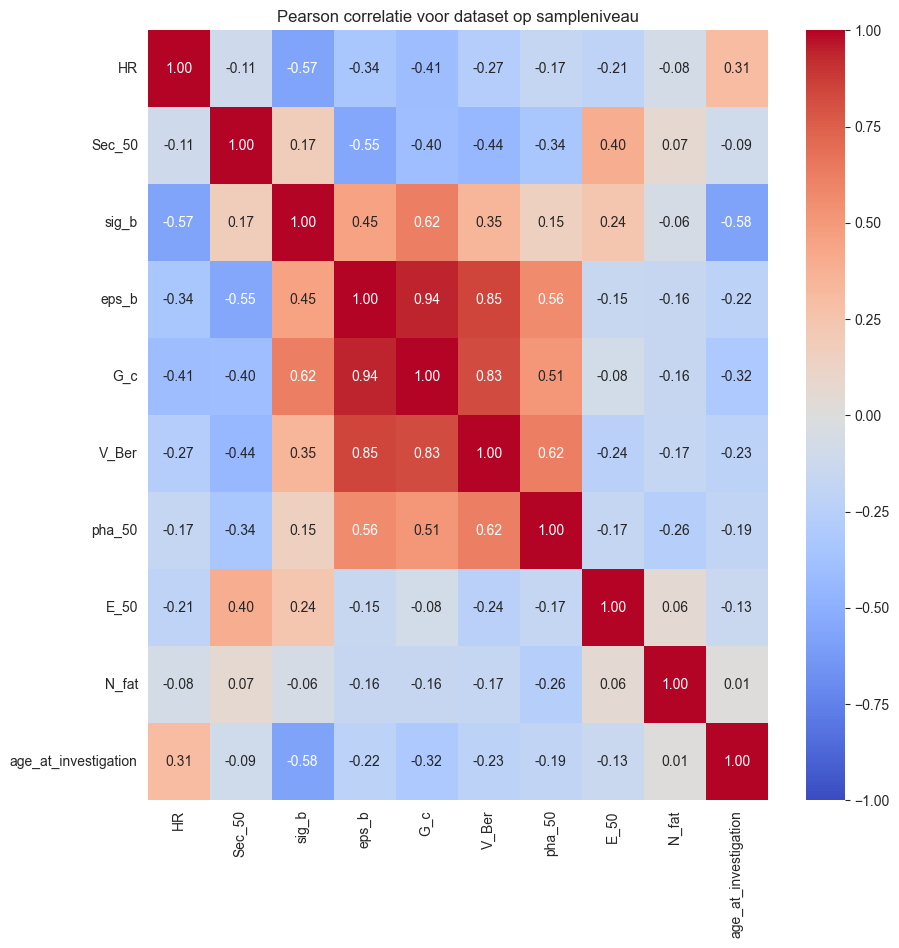

In [17]:
#compute correlation matrix of df_final for columns 'v', 'Sec_10', 'Sec_50', 'Sec_100', 'sig_b', 'eps_b', 'G_c', 'G_c_over_eps_b', 'G_c_over_eps_b_sig_b', 'V_Ber' 'pha_ini', 'pha_50', 'sig_cyc', 'sig_perm', 'E_ini', 'E_50', 'N_fat', 'age_at_investigation'
correlation_matrix_pearson = df_final[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
# correlation_matrix_spearman = df_final[['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('kendall')
#plot correlation matrix as heatmap
fig, ax = plt.subplots(figsize=(10,10),)
sns.heatmap(correlation_matrix_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
# sns.heatmap(correlation_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax2)
ax.set_title('Pearson correlatie voor dataset op sampleniveau')


Text(0.5, 1.0, 'Homogeen')

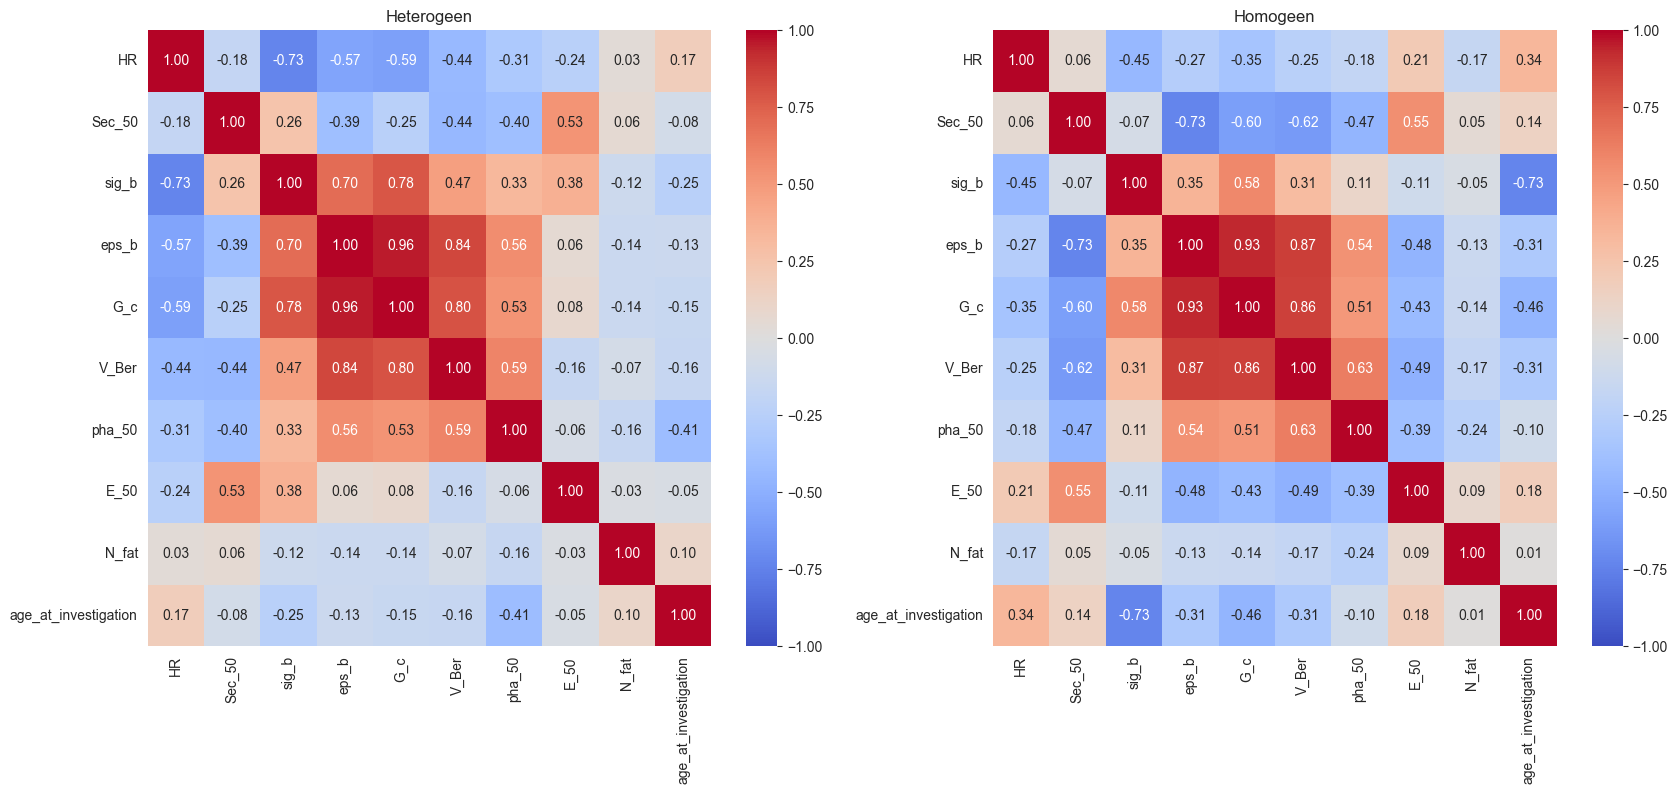

In [18]:
correlation_matrix_pearson_heterogeen = df_final.loc[df_final.heterogeneity_category == 'Heterogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
correlation_matrix_pearson_homogeen = df_final.loc[df_final.heterogeneity_category == 'Homogeen'][['HR', 'Sec_50', 'sig_b', 'eps_b', 'G_c', 'V_Ber', 'pha_50', 'E_50', 'N_fat', 'age_at_investigation']].corr('pearson')
#plot both as heatmaps side by side
fig, ax = plt.subplots(figsize=(20,8), ncols=2)
sns.heatmap(correlation_matrix_pearson_heterogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[0])
sns.heatmap(correlation_matrix_pearson_homogeen, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1])
ax[0].set_title('Heterogeen')
ax[1].set_title('Homogeen')

### bros versus ductiel


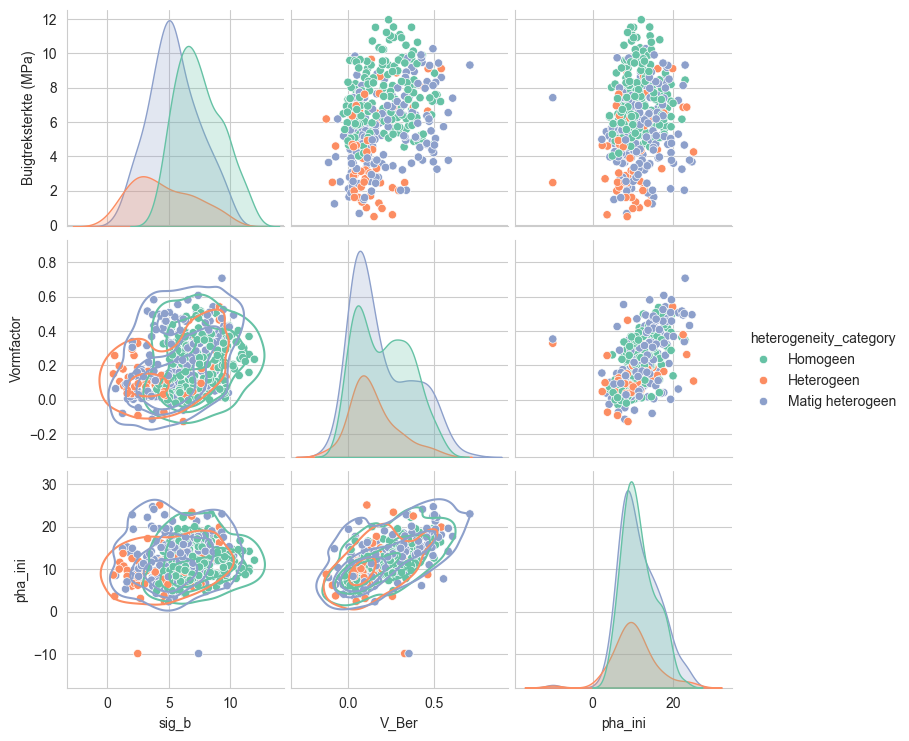

In [19]:
#pairplot of df_final with columns sig_b, V_Ber, pha_ini
g = sns.pairplot(df_final.loc[df_final.pha_ini < 1e6], vars=['sig_b', 'V_Ber', 'pha_ini'], hue='heterogeneity_category', palette='Set2', diag_kind='kde')
g.map_lower(sns.kdeplot, levels=4, color=".2")
#change y-labels to fasehoek, vormfactor en buigtreksterkte
g.axes[0,0].set_ylabel('Buigtreksterkte (MPa)')
g.axes[1,0].set_ylabel('Vormfactor')
g.axes[0,1].set_ylabel('Fasehoek (°)')
#same for xlabels
g.axes[0,0].set_xlabel('Buigtreksterkte (MPa)')
g.axes[1,0].set_xlabel('Vormfactor')
g.axes[0,1].set_xlabel('Fasehoek (°)')

plt.show()

### Regio

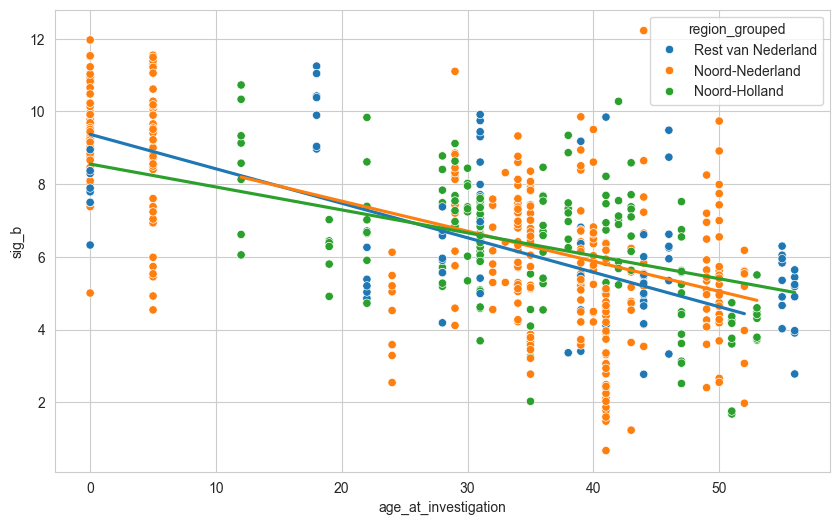

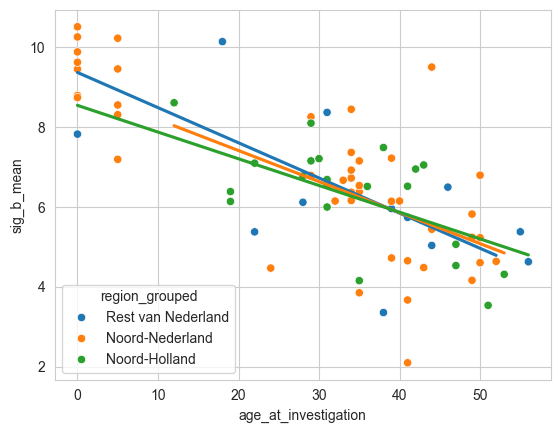

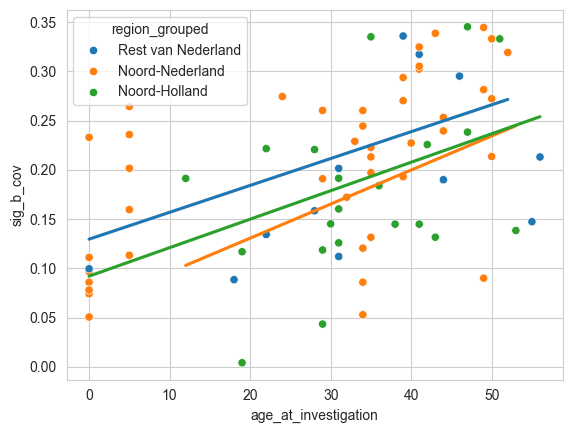

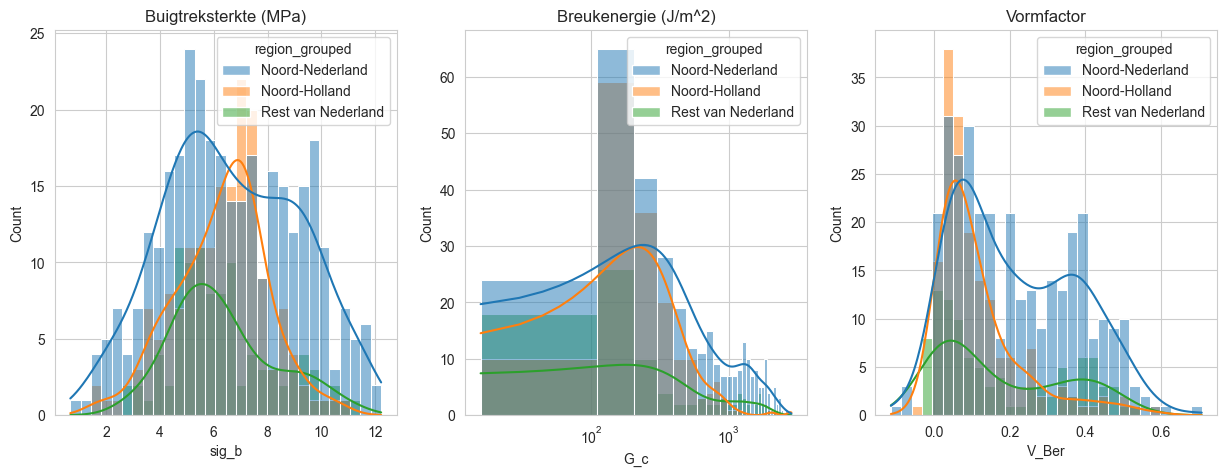

In [20]:
df_final['waterboard'].unique()
#translation dictionary to get consistent names:
region_dict = {'Hollandse Delta': 'Zuid Hollandse Delta',
 'Rijkswaterstaat Zuid-Holland Waterdistrict Haringvliet': 'Zuid Hollandse Delta',
'Wetterskip Fryslân': 'Friesland', 
'Noorderzijlvest': 'Groningen',
"{'emmapolder_47,5 - 57': 'Noorderzijlvest'}": 'Groningen',
"{'noorderhavendam_0 - 1,206': 'Wetterskip Fryslân'}": "Friesland",
"HHNK": "Noord-Holland",
'Waterschap Noorderzijlvest': "Groningen",
"{'zuidelijke_dijken_goeree_vak_1_42,525 - 43,04': 'Hollandse Delta'}": 'Zuid Hollandse Delta',
'PWN': "Noord-Holland", 'Groningen Seaports': "Groningen", 'Waterschap Scheldestromen': "Zeeland",
'Waterschap Hollandse Delta': "Zuid Hollandse Delta", 'Rijkswaterstaat': "Rijkswaterstaat",
'Havenbedrijf Rotterdam': "Zuid Hollandse Delta", 'Waterschap Zuiderzeeland': "Flevoland"}
df_final['region'] = df_final['waterboard'].map(region_dict)

#make a distinction of data where region is Groningen or Friesland vs Noord-Holland, vs rest of the Netherlands
df_final['region_grouped'] = df_final['region'].apply(lambda x: 'Noord-Nederland' if x in ['Groningen', 'Friesland'] else ('Noord-Holland' if x == 'Noord-Holland' else 'Rest van Nederland'))

plot_data = df_final.loc[df_final.heterogeneity_category != 'Heterogeen']
#plot age_at_investigation vs sig_b, colored by region
fig,ax= plt.subplots(figsize=(10,6))
sns.scatterplot(data=plot_data, x='age_at_investigation', y='sig_b', hue='region_grouped', palette='tab10',ax=ax)
#make simple regression line for each region_grouped
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)
sns.regplot(data=plot_data.loc[plot_data['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b', ci=None,ax=ax, scatter=False)

#also map to data_per_dike_project
data_per_dike_project['region'] = data_per_dike_project['waterboard'].map(region_dict)
data_per_dike_project['region_grouped'] = data_per_dike_project['region'].apply(lambda x: 'Noord-Nederland' if x in ['Groningen', 'Friesland'] else ('Noord-Holland' if x == 'Noord-Holland' else 'Rest van Nederland'))
plot_data_region = data_per_dike_project.loc[data_per_dike_project.heterogeneity_category != 'Heterogeen']
#plot age_at_investigation vs sig_b_mean, colored by 
plt.subplots()
sns.scatterplot(data=plot_data_region, x='age_at_investigation', y='sig_b_mean', hue='region_grouped', palette='tab10')
#also regplots here
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b_mean', ci=None, scatter=False)


#also make it for sig_b_cov
plt.subplots()
sns.scatterplot(data=plot_data_region, x='age_at_investigation', y='sig_b_cov', hue='region_grouped', palette='tab10')
#also regplots here
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Nederland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Noord-Holland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)
sns.regplot(data=plot_data_region.loc[plot_data_region['region_grouped'] == 'Rest van Nederland'], x='age_at_investigation', y='sig_b_cov',
            ci=None, scatter=False)

#plot the distributions for each region_grouped
fig, ax = plt.subplots(figsize=(15,5), ncols=3)
sns.histplot(data=plot_data, x='sig_b', hue='region_grouped', palette='tab10', ax=ax[0], bins=30, kde=True,hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='G_c', hue='region_grouped', palette='tab10', ax=ax[1], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
sns.histplot(data=plot_data, x='V_Ber', hue='region_grouped', palette='tab10', ax=ax[2], bins=30, kde=True, hue_order=['Noord-Nederland', 'Noord-Holland', 'Rest van Nederland'])
ax[0].set_title('Buigtreksterkte (MPa)')
ax[1].set_title('Breukenergie (J/m^2)')
ax[2].set_title('Vormfactor')
ax[1].set_xscale('log')